In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install shap -q
!pip install hydra-core -q
!pip install fedlab -q
!pip install lime -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.0/117.0 kB 1.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 6.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.2/60.2 kB 2.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 122.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 100.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 58.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import random
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import copy
import statistics
import pandas as pd
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import yaml
import os
from fedlab.utils.dataset.partition import  BasicPartitioner
from torch.utils.data import Subset
import matplotlib.pyplot as plt
from collections import OrderedDict
import concurrent.futures
from concurrent.futures import ThreadPoolExecutor, as_completed
import shap
import hydra
from hydra.core.hydra_config import HydraConfig
from omegaconf import DictConfig, OmegaConf
import random
import numpy as np
import torch
# Set seed for Python's random module
random.seed(42)
# Set seed for NumPy
np.random.seed(42)
# Set seed for PyTorch
torch.manual_seed(42)
import numpy as np
import torch
import torch.nn.functional as F
import random
from lime.lime_tabular import LimeTabularExplainer
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import os
import numpy as np
import torch
import torch.nn.functional as F
import random
from lime.lime_tabular import LimeTabularExplainer
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import os

# If you are using CUDA, you may also want to set the seed for GPU operations
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.cuda.manual_seed_all(42)  # For all GPUs if you have multiple


In [ ]:
class ANNModel(nn.Module):
    def __init__(self, input_features=8):
        super(ANNModel, self).__init__()

        # Fully connected layers for a simple ANN
        self.fc1 = nn.Linear(input_features, 16)  # First hidden layer with 64 neurons
        self.fc2 = nn.Linear(16, 8)  # Second hidden layer with 32 neurons
        self.fc3 = nn.Linear(8, 1)  # Output layer for binary classification

        # Dropout layer to reduce overfitting
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        # Forward pass through fully connected layers with ReLU and dropout
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x



def train(net, trainloader, optimizer, epochs):
    """
    Train a neural network model using a specified optimizer and dataset.

    This function trains the provided network on a training set for a specified number of epochs,
    computing the loss with `BCEWithLogitsLoss`. It also reports the total training time taken.

    Args:
        net (torch.nn.Module): The neural network model to be trained.
        trainloader (torch.utils.data.DataLoader): DataLoader for the training set, which yields input features and labels.
        optimizer (torch.optim.Optimizer): The optimizer to use for updating the network's weights.
        epochs (int): The number of training epochs (iterations over the full dataset).

    Returns:
        float: The total time (in seconds) taken to complete the training process.
    """
    criterion = nn.BCEWithLogitsLoss()
    net.train()

    start_time = time.time()  # Start time for the training

    for _ in range(epochs):
        for features, labels in trainloader:
            optimizer.zero_grad()
            output = net(features)
            loss = criterion(output.squeeze(1), labels.float())
            loss.backward()
            optimizer.step()


        #sleep_time = random.uniform(0, 3)
        time.sleep(1)


    end_time = time.time()  # End time for the training
    total_time = end_time - start_time

    return total_time

def evaluate_model(model, test_loader):
    """
    Evaluate a trained neural network model on a test dataset.

    This function computes the average loss, accuracy, precision, recall, F1 score, and confusion matrix for the model
    on the test set, using `binary_cross_entropy_with_logits` as the loss function. It assumes a binary classification task.

    Args:
        model (torch.nn.Module): The trained neural network model to evaluate.
        test_loader (torch.utils.data.DataLoader): DataLoader for the test set, which yields input features and labels.

    Returns:
        tuple:
            avg_loss (float): The average loss over the test set.
            accuracy (float): The accuracy of the model on the test set.
            precision (float): The precision score of the model.
            recall (float): The recall score of the model.
            f1 (float): The F1 score of the model.
            conf_matrix (numpy.ndarray): Confusion matrix of the model's predictions.
    """
    model.eval()  # Set the model to evaluation mode

    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for data, labels in test_loader:
            data, labels = data, labels
            outputs = model(data)
            outputs = outputs.squeeze(1)
            loss = F.binary_cross_entropy_with_logits(outputs, labels.float())

            total_loss += loss.item() * data.size(0)
            preds = torch.round(torch.sigmoid(outputs))
            total_correct += (preds == labels).sum().item()
            total_samples += data.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / total_samples
    accuracy = total_correct / total_samples
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    conf_matrix = confusion_matrix(all_labels, all_preds)

    return avg_loss, accuracy, precision, recall, f1, conf_matrix

In [ ]:
def weighted_aggregation(w, agg_weights):
    """
    Returns the average of the weights.
    """
    w_avg = copy.deepcopy(w[0].state_dict())
    total_agg_weights = sum(agg_weights)

    for key in w_avg.keys():
        w_avg[key] *= (agg_weights[0] / total_agg_weights)
    for key in w_avg.keys():
        for i in range(1, len(w)):
            w_avg[key] += w[i].state_dict()[key] * (agg_weights[i] / total_agg_weights)
    return w_avg

import copy
from collections import OrderedDict

def weighted_aggregation(w, agg_weights):
    """
    Returns the weighted average of the weights.

    Parameters:
    w (list): A list of model instances or state dicts.
    agg_weights (list): A list of weights corresponding to each model/state dict.

    Returns:
    OrderedDict: The weighted average of the weights.
    """
    # Check if w is a list of model instances or state dicts
    if hasattr(w[0], 'state_dict'):
        # w is a list of model instances
        w_avg = copy.deepcopy(w[0].state_dict())
    else:
        # w is a list of state dicts (OrderedDict)
        w_avg = copy.deepcopy(w[0])

    total_agg_weights = sum(agg_weights)

    for key in w_avg.keys():
        w_avg[key] *= (agg_weights[0] / total_agg_weights)

    for key in w_avg.keys():
        for i in range(1, len(w)):
            if hasattr(w[i], 'state_dict'):
                # If w[i] is a model instance
                w_avg[key] += w[i].state_dict()[key] * (agg_weights[i] / total_agg_weights)
            else:
                # If w[i] is a state dict
                w_avg[key] += w[i][key] * (agg_weights[i] / total_agg_weights)

    return w_avg

def get_label_distribution(dataloader):
    labels = []
    for _, batch_labels in dataloader:
    # Append the batch of labels to the list
        labels.extend(batch_labels.tolist())
    return labels

def get_data_size(dataloader):
    return len(get_label_distribution(dataloader))

def get_labels_variance(dataloader):
    return statistics.variance(get_label_distribution(dataloader))


def analyze_dataloaders(dataloaders):
    """
    Analyze the data distribution of multiple DataLoader objects across different clients.

    This function calculates the label distribution, variance, and number of samples for each client
    from a list of DataLoader objects, which represent the data split for each client. It prints out
    details such as the set of unique labels, the number of samples, and label counts for each client.

    Args:
        dataloaders (list of torch.utils.data.DataLoader): A list of DataLoader objects, where each DataLoader corresponds to a client's data.
        client_ids (list of int or str): A list of client identifiers, which can be integers or strings, corresponding to each DataLoader.

    Returns:
        tuple:
            - label_distribution_per_client (list of list): A list of label distributions for each client. Each element contains the labels from one client's DataLoader.
            - variance_per_client (list of float): A list of variances in label distribution for each client.
            - num_samples_per_client (list of int): A list of the number of samples in each client's dataset.

    Prints:
        - Client ID and associated label information (unique labels, number of samples, label counts).
    """
    label_distribution_per_client = []
    variance_per_client = []
    num_samples_per_client = []
    j = 0

    for dataloader in dataloaders:
        labels = []

        for _, batch_labels in dataloader:
            # Append the batch of labels to the list
            labels.extend(batch_labels.tolist())

        label_distribution_per_client.append(labels)
        variance_per_client.append(statistics.variance(labels))
        num_samples_per_client.append(len(labels))

        # Count occurrences of each label
        label_counts = collections.Counter(labels)

        print("Label Category in Vehicle", j, ':', set(labels))
        print("Number of Samples in Vehicle", j, ':', num_samples_per_client[j])
        print("Label Counts in Vehicle", j, ':', dict(label_counts))  # Display value counts for each label
        print("*********")

        j += 1



def distribute_clients(trainloaders, num_nodes ,method='equal'):
    trainloaders_node = []
    num_clients = len(trainloaders)
    if method == 'equal':
        step = num_clients // num_nodes
        for i in range(0, num_clients, step):
            if i + step > num_clients:
                trainloaders_node.append(trainloaders_node[i:])
            else:
                trainloaders_node.append(trainloaders[i:i+step])

        return trainloaders_node
    elif method == 'random':
        steps = generate_random_list(num_nodes, num_clients)
        i = 0
        for step in steps:
            if step != 0:
                if i + step > num_clients:
                    trainloaders_node.append(trainloaders[i:])
                else:
                    trainloaders_node.append(trainloaders[i:i+step])
            else:
                trainloaders_node.append([])
            i = step

        return trainloaders_node


#def divide_list_randomly(lst, M, min_size=3, max_size=8):
#    """
#    Divide a list into M random sublists with specified min and max sizes.
#
#    Args:
#        lst (list): The list to be divided.
#        M (int): The number of sublists to create.
#        min_size (int): Minimum number of items in each sublist.
#        max_size (int): Maximum number of items in each sublist.
#
#    Returns:
#        list: A list of M sublists created from the original list.
#
#    Raises:
#        ValueError: If M is greater than the number of elements in the list or
#                     if it is impossible to divide the list within the given limits.
#    """
#    N = len(lst)
#
#    if M > N:
#        raise ValueError("M cannot be greater than the number of elements in the list")
#
#    if M * min_size > N or M * max_size < N:
#        raise ValueError("Cannot divide the list into M sublists with the given min and max size constraints.")
#
#    # Shuffle the list to ensure random distribution
#    random.shuffle(lst)
#    sublists = []
#    remaining_vehicles = lst[:]
#
#    # Calculate the average number of vehicles per edge server
#    avg_size = N // M
#
#    for i in range(M):
#        if i == M - 1:
#            # Assign the remaining vehicles to the last sublist
#            sublist = remaining_vehicles
#        else:
#            # Choose a random size for this sublist, ensuring min_size <= sublist_size <= max_size
#            sublist_size = random.randint(min_size, min(max_size, len(remaining_vehicles) - (M - i - 1) * min_size))
#            sublist = remaining_vehicles[:sublist_size]
#            remaining_vehicles = remaining_vehicles[sublist_size:]
#
#        sublists.append(sublist)
#
#    print(f"Spread {N} clients across {len(sublists)} edges, with each edge receiving a subset of clients.")
#    return sublists




def divide_list_randomly(lst, M):
    """
    Divide a list into M random sublists with each sublist having at least one element.

    Args:
        lst (list): The list to be divided.
        M (int): The number of sublists to create.

    Returns:
        list: A list of M sublists created from the original list.

    Raises:
        ValueError: If M is greater than the number of elements in the list.
    """
    N = len(lst)

    if M > N:
        raise ValueError("M cannot be greater than the number of elements in the list")

    # Shuffle the original list to randomize the indices
    shuffled_list = lst[:]
    random.shuffle(shuffled_list)

    # Allocate 1 element to each sublist to ensure the condition
    sublist_sizes = [1] * M
    remaining_elements = N - M

    # Distribute remaining elements randomly across the sublists
    for _ in range(remaining_elements):
        sublist_sizes[random.randint(0, M - 1)] += 1

    # Divide the shuffled list into M random sublists based on generated sizes
    sublists = []
    start = 0
    for size in sublist_sizes:
        sublists.append(shuffled_list[start:start + size])
        start += size

    print(f"Spread {N} clients across {M} edges, with each edge receiving a random subset of clients.")
    return sublists



In [ ]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_flag_distribution(df, class_labels=None):
    """
    Plots the distribution of the 'flag' column in the dataset.

    Parameters:
        df (pd.DataFrame): The dataframe containing the 'flag' column.
        class_labels (dict, optional): A dictionary to map flag values to meaningful class names.
                                       Example: {"R": "Normal", "T": "Attack"}.
    """
    sns.countplot(x="label", data=df, palette="viridis", hue="label", legend=False)
    plt.title("Flag Value Counts")
    if class_labels:
        plt.xticks(
            ticks=range(len(class_labels)),
            labels=[class_labels[label] for label in class_labels]
        )
    plt.show()

def preprocess_dataset():
    processed_file = "/content/drive/MyDrive/car_hacking_dataset/Dataset/Car_Hacking_preprocessed_dataset.csv"
    class_labels = {"R": "Normal", "T": "Attack"}

    # Load processed dataset if it exists
    if os.path.isfile(processed_file):
        df = pd.read_csv(processed_file)
        if "flag" in df.columns and "label" not in df.columns:
            df.rename(columns={"flag": "label"}, inplace=True)
        plot_flag_distribution(df, class_labels)
        return df

    # Raw data file paths
    raw_files = {
        "normal": "/content/drive/MyDrive/Normal_data.csv",
        "dos": "/content/drive/MyDrive/DoS_dataset.csv",
        "fuzzy": "/content/drive/MyDrive/Fuzzy_dataset.csv",
        "gear": "/content/drive/MyDrive/gear_dataset.csv",
        "rpm": "/content/drive/MyDrive/RPM_dataset.csv"
    }

    column_names = ["Timestamp", "ID", "DLC", "Byte1", "Byte2", "Byte3", "Byte4", "Byte5", "Byte6", "Byte7", "Byte8", "flag"]
    dataframes = []

    # Load and process raw files
    for key, path in raw_files.items():
        df = pd.read_csv(path, names=column_names, index_col=False) if key != "normal" else pd.read_csv(path, index_col=False)
        if key == "normal":
            df["flag"] = "R"  # Assign flag for normal data
        dataframes.append(df)

    # Combine all datasets
    df = pd.concat(dataframes, axis=0, ignore_index=True)
    print(f"Total data shape before removing missing data: {df.shape}")

    # Drop rows with missing data
    df.dropna(inplace=True)
    print(f"Total data shape after removing missing data: {df.shape}")

    # Convert Hexadecimal Byte columns to Decimal and drop original Byte columns
    byte_columns = [f"Byte{i}" for i in range(1, 9)]
    for i, byte_col in enumerate(byte_columns):
        df[f"DATA_{i}"] = df[byte_col].apply(lambda x: int(str(x), 16))
    df.drop(columns=byte_columns, inplace=True)

    # Drop unnecessary columns
    df.drop(columns=["Timestamp", "ID", "DLC"], inplace=True)

    # Remove duplicate rows
    df.drop_duplicates(inplace=True)
    print(f"Data shape after removing duplicate entries: {df.shape}")

    # Save the processed dataset
    os.makedirs(os.path.dirname(processed_file), exist_ok=True)
    df.to_csv(processed_file, index=False)

    # Visualize and rename flag column
    plot_flag_distribution(df, class_labels)
    if "flag" in df.columns and "label" not in df.columns:
        df.rename(columns={"flag": "label"}, inplace=True)

    return df



def prepare_training_testing_data(dataset, test_size=0.30, output_dir="/content/drive/MyDrive/car_hacking_dataset/Dataset"):
    """
    Prepares and pre-processes the dataset for training and testing.

    This function shuffles the dataset, encodes labels, scales features, and splits the data
    into training and testing sets. It also saves the processed training and testing data into CSV files.

    Args:
        dataset (pd.DataFrame): The input dataset containing features and labels.
        test_size (float, optional): Proportion of the dataset to be used for testing. Defaults to 0.30.
        output_dir (str, optional): Directory where processed files will be saved. Defaults to a specified path.

    Returns:
        tuple:
            X_train_scaled (numpy.ndarray): Scaled feature matrix for the training set.
            X_test_scaled (numpy.ndarray): Scaled feature matrix for the test set.
    """
    # Shuffle the dataset
    dataset = dataset.sample(frac=1, random_state=42).reset_index(drop=True)

    # Encode labels
    label_mapping = {"R": 0, "T": 1}
    dataset['label'] = dataset['label'].map(label_mapping)

    # Split into train and test sets
    train_df, test_df = train_test_split(dataset, test_size=test_size, stratify=dataset['label'], random_state=42)

    # Split features and labels
    X_train, y_train = train_df.drop(columns=['label']), train_df['label']
    X_test, y_test = test_df.drop(columns=['label']), test_df['label']

    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Prepare scaled datasets for saving
    train_df_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
    train_df_scaled['label'] = y_train.values

    test_df_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)
    test_df_scaled['label'] = y_test.values

    # Save processed datasets
    os.makedirs(output_dir, exist_ok=True)
    train_df_scaled.to_csv(os.path.join(output_dir, "car_hacking_trainset.csv"), index=False)
    test_df_scaled.to_csv(os.path.join(output_dir, "car_hacking_testset.csv"), index=False)

    return X_train_scaled, X_test_scaled

def get_car_hacking_dataset():
    """
    Loads and prepares the CiCiov dataset for training and testing in PyTorch format.

    This function reads the pre-processed train and test CSV files, converts the data into PyTorch tensors,
    and creates TensorDataset objects for both the training and testing data. It also returns the target labels
    separately for both the train and test sets.

    Args:
        None

    Returns:
        tuple:
            train_tensor (torch.utils.data.TensorDataset): Tensor dataset containing training features and labels.
            test_tensor (torch.utils.data.TensorDataset): Tensor dataset containing test features and labels.
            train_target (torch.Tensor): Tensor containing training labels.
            test_target (torch.Tensor): Tensor containing test labels.
    """
    train = pd.read_csv('/content/drive/MyDrive/car_hacking_dataset/Dataset/car_hacking_trainset.csv')
    test = pd.read_csv('/content/drive/MyDrive/car_hacking_dataset/Dataset/car_hacking_testset.csv')
    train_target = torch.tensor(train['label'].values.astype(np.float32))
    train = torch.tensor(train.drop('label', axis = 1).values.astype(np.float32))
    train_tensor = TensorDataset(train, train_target)

    test_target = torch.tensor(test['label'].values.astype(np.float32))
    test = torch.tensor(test.drop('label', axis = 1).values.astype(np.float32))
    test_tensor = TensorDataset(test, test_target)

    return train_tensor , test_tensor ,train_target,test_target

In [ ]:
### Undersampling,Stratified Sampling while splitting and testing
def get_all_labels(dataset):
    all_labels = []

    for _, labels in dataset:
        all_labels.append(labels)
    all_labels_tensor = torch.stack(all_labels)

    return all_labels_tensor



def get_plot_label_distribution(train, test):
    train_0, train_1 = train['label'].value_counts()[0] / len(train.index), train['label'].value_counts()[1] / len(train.index)
    test_0, test_1 = test['label'].value_counts()[0] / len(test.index), test['label'].value_counts()[1] / len(test.index)
    print("In Train: there are {} % of class 0 and {} % of class 1".format(train_0, train_1))
    print("In Test: there are {} % of class 0 and {} % of class 1".format(test_0, test_1))
    # Plotting target label distribution
    plt.figure()
    plt.title("class distribution of train and test dataset")
    train['label'].value_counts().plot(kind="bar", color='b', label="train")
    test['label'].value_counts().plot(kind="bar", color='orange', label="test")
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.legend()
    plt.show()

def split_dataset(train_set, test_set ,num_clients, batch_size ,partition='iid', dir_alpha=None ,major_classes_num=0):
    """
    Split the dataset into multiple clients for federated learning.

    Args:
        train_set (Dataset): The training dataset to be partitioned.
        test_set (Dataset): The testing dataset.
        num_clients (int): The number of clients to split the data among.
        batch_size (int): The batch size for the data loaders.
        partition (str): The type of partitioning ('iid' for independent and identically distributed).
        dir_alpha (float, optional): Dirichlet parameter for non-iid partitioning.
        major_classes_num (int, optional): Number of major classes for partitioning.

    Returns:
        list: A list of DataLoaders for the training sets of each client.
        DataLoader: A DataLoader for the test set.
    """
    partitioner = BasicPartitioner(get_all_labels(train_set) ,num_clients, partition=partition, dir_alpha=dir_alpha ,major_classes_num= major_classes_num, seed=2023)
    trainloaders =[]

    for client in range(num_clients):
        idx = partitioner.client_dict[client]
        trainset_ = Subset(train_set, idx)

        trainloaders.append(
            DataLoader(trainset_, batch_size=batch_size, shuffle=True)
        )


    testloader = DataLoader(test_set, batch_size=batch_size)

    # Create a DataLoader for the Training data to get trainig loss
    raw_train_loader = DataLoader(train_set, batch_size=batch_size)
    return raw_train_loader ,trainloaders, testloader


In [ ]:
''' #  Preprocess the Dataset and ge
df = preprocess_dataset()

# Pre-process the dataset by splitting it into training and testing sets
# The parameter test_size=0.3 indicates that 30% of the data will be used for testing
x_train, x_test = prepare_training_testing_data(df,test_size=0.3)

# Convert the training data (x_train) into a PyTorch tensor of type float32
X_train_tensor = torch.tensor(x_train, dtype=torch.float32)

# Convert the testing data (x_test) into a PyTorch tensor of type float32
X_test_tensor = torch.tensor(x_test, dtype=torch.float32)

# Load the dataset for a specific application (CICIDS dataset)
# The function returns training and testing datasets, as well as their corresponding targets
trainset, testset, train_target, test_target = get_car_hacking_dataset() '''


' #  Preprocess the Dataset and ge\ndf = preprocess_dataset()\n\n# Pre-process the dataset by splitting it into training and testing sets\n# The parameter test_size=0.3 indicates that 30% of the data will be used for testing\nx_train, x_test = prepare_training_testing_data(df,test_size=0.3)\n\n# Convert the training data (x_train) into a PyTorch tensor of type float32\nX_train_tensor = torch.tensor(x_train, dtype=torch.float32)\n\n# Convert the testing data (x_test) into a PyTorch tensor of type float32\nX_test_tensor = torch.tensor(x_test, dtype=torch.float32)\n\n# Load the dataset for a specific application (CICIDS dataset)\n# The function returns training and testing datasets, as well as their corresponding targets\ntrainset, testset, train_target, test_target = get_car_hacking_dataset() '

In [ ]:
import random

class EdgeServer():
    def __init__(self, vehicles, config, id):
        self.vehicles = vehicles
        self.local_model_storage = []
        self.agg_weight = []
        self.model = ANNModel()
        self.config = config
        self.id = id
        self.current_version = 0  # Edge server version
        self.training_queue = []
        self.trained_vehicles_last_round = []

    def continous_update_with_version_control(self, cloud_server, staleness_threshold):
        """
        Continuously updates the edge server model using vehicles while implementing version control.
        The function trains selected vehicles and updates the global model on the cloud server
        if the vehicles' versions are not stale (i.e., within the staleness threshold).

        Parameters:
            cloud_server (CloudServer): The cloud server instance that manages the global model.
            staleness_threshold (int): The version difference threshold for considering a model
                                        as stale. If the version difference exceeds this, the
                                        model update will be discarded.

        Returns:
            list: A list of training times for each vehicle that participated in the training round.

        Notes:
            - Vehicles that trained in the last round are excluded from selection to promote diversity.
            - Local model storage and aggregation weights are reset before training each vehicle.
            - The function prints logs of training details, model updates, and any vehicles whose
            updates were discarded due to staleness.
        """
        #self.trained_vehicles_last_round = []
        def train_vehicle(self, vehicle, cloud_server):
            #vehicle.set_parameters(self.model.state_dict().values())
            w_vehicle, data_size_vehicle, vehicle_time, vehicle_version = vehicle.fit(self.config)

            if abs(vehicle_version - self.current_version) <= staleness_threshold:
                # Clear previous local model storage and aggregation weights
                self.local_model_storage = []
                self.agg_weight = []
                self.training_queue.append(vehicle)
                self.local_model_storage.append(w_vehicle)
                self.agg_weight.append(data_size_vehicle)

                print(f"[Edge Server] Edge ID: {self.id} - Model trained by Vehicle ID: {vehicle.id} - "
                      f"Data size: {data_size_vehicle} - Training time: {vehicle_time:.2f}s, Vehicle Version: {vehicle_version}")

                self.aggregate_local_models()
                # Add vehicle ID to the list of trained vehicles
                self.trained_vehicles_last_round.append(vehicle.id)

                cloud_server.update_global_model()  # Update cloud server with edge server model
                print(f"[Cloud Server] Global model updated after training by Vehicle ID: {vehicle.id} from Edge server: {self.id}")
                cloud_server.update_edge_servers()
                self.update_training_queue_vehicles()
                print(f"Global model is diffused to edge servers and vehicles  and cloud server New version :{cloud_server.current_version} and {self.id} edge server New version :{self.current_version}")

                """
                if abs(self.current_version - cloud_server.current_version) <= staleness_threshold:
                    cloud_server.update_global_model()  # Update cloud server with edge server model
                    cloud_server.update_edge_servers()
                    self.update_training_queue_vehicles()

                    print(f"[Cloud Server] Global model updated after training by Vehicle ID: {vehicle.id} from Edge server: {self.id}")
                else:
                    print(f"[Cloud Server] Discarding stale model from Edge ID: {self.id}, Edge server {self.id} Version: {self.current_version}, cloud server version {cloud_server.current_version}")
                """
            else:
                print(f"[Edge Server] Discarding stale model from Vehicle ID: {vehicle.id}, Version: {vehicle_version}")

            # Track the vehicle as trained in this round
            #self.trained_vehicles_last_round.add(vehicle.id)

            return vehicle_time

        # Select vehicles for this round, skipping those that contributed in the last round
        active_vehicles = self.select_active_vehicles()

        args = [(self, vehicle, cloud_server) for vehicle in active_vehicles]

        with concurrent.futures.ThreadPoolExecutor() as executor:
            results = list(executor.map(lambda p: train_vehicle(*p), args))
        print(f"The vehicles trained on this round are: {self.trained_vehicles_last_round}")
        self.update_vehicles()
        return results

    def select_active_vehicles(self):
        """
        Selects 80% of vehicles randomly for Federated Dropout, excluding vehicles that participated
        in the training during the last round. This helps ensure diversity in the training set and
        prevents overfitting to the same set of vehicles.

        Returns:
            list: A list of selected active vehicles for the current training round.

        Notes:
            - The function first filters out vehicles that trained in the last round from the list of
            available vehicles.
            - It then randomly selects 80% of the remaining vehicles to participate in the current round
            of training.
            - If fewer than 80% of available vehicles remain, it selects all of them.
            - The function also logs the vehicles that were dropped either because they trained in the last
            round or due to Federated Dropout.
        """
        # Filter out vehicles that trained in the last round
        available_vehicles = [v for v in self.vehicles if v.id not in self.trained_vehicles_last_round]
        dropped_last_round = [v for v in self.vehicles if v.id in self.trained_vehicles_last_round]

        # Federated Dropout: Select 80% of the available vehicles randomly
        active_vehicles_count = int(0.8 * len(available_vehicles))

        # Handle case where available_vehicles might be less than 80%
        if active_vehicles_count > 0 and len(available_vehicles) > 0:
            active_vehicles = random.sample(available_vehicles, active_vehicles_count)
        else:
            active_vehicles = available_vehicles  # Select all available vehicles if count is too small

        # If no active vehicles are available, reset to the initial stage
        if not active_vehicles:
            print(f"[Edge Server {self.id}] All vehicles are either trained or dropped. Resetting training process.")
            self.reset_training()
            return []


        # Find vehicles dropped due to Federated Dropout
        dropped_federated = [v for v in available_vehicles if v not in active_vehicles]

        # Print details about vehicles dropped due to training in the last round
        if dropped_last_round:
            print(f"[Edge Server {self.id}] Vehicles dropped for this round because they trained last round: "
                  f"{[v.id for v in dropped_last_round]}")

        # Print details about vehicles dropped due to Federated Dropout
        if dropped_federated:
            print(f"[Edge Server {self.id}] Vehicles dropped due to Federated Dropout: "
                  f"{[v.id for v in dropped_federated]}")

        # Log the total number of dropped vehicles
        print(f"[Edge Server {self.id}] Total dropped vehicles: {len(dropped_last_round) + len(dropped_federated)}")

        return active_vehicles

    def reset_training(self):
        """
        Resets the edge server to its initial state for the next round of training.
        """
        self.current_version = 0
        self.local_model_storage = []
        self.agg_weight = []
        self.training_queue = []
        self.trained_vehicles_last_round = []
        print(f"[Edge Server {self.id}] Training process reset. Ready for a new round of training.")

    def update_training_queue_vehicles(self):
        """
        Updates the parameters of all vehicles in the training queue and clears the queue.

        This function iterates over all vehicles in the `self.training_queue` list, updates their parameters
        by calling the `set_parameters()` method using the current parameters retrieved by `self.get_parameters()`,
        and then clears the training queue once all vehicles have been updated.

        Args:
            self: Instance of the class containing the `training_queue` attribute, which is expected to be a list of vehicle objects.

        Returns:
            None: The function updates the parameters of vehicles and clears the `training_queue` list.
        """
        for vehicle in self.training_queue:
            vehicle.set_parameters(self.get_parameters())
            vehicle.version=self.current_version
        # Clear the training queue after updating vehicles
        self.training_queue.clear()

    def set_parameters(self ,parameters):
        """Receive parameters and apply them to the local model."""
        params_dict = zip(self.model.state_dict().keys(), parameters)

        state_dict = OrderedDict({k: torch.Tensor(v) for k, v in params_dict})

        self.model.load_state_dict(state_dict, strict=True)

    def get_parameters(self):
        """Extract model parameters and return them as a list of numpy arrays."""

        return [val.cpu().numpy() for _, val in self.model.state_dict().items()]

    def aggregate_local_models(self):
        """
        Aggregates the local models stored in the edge server using weighted aggregation based on their
        associated weights. This function updates the edge server's model parameters and increments
        the model version.

        Args:
            self: The instance of the class containing local model storage and other necessary attributes.

        Returns:
            None: This function does not return a value; it directly modifies the edge server's model parameters.

        Notes:
            - The aggregation process combines the parameters of local models stored in `self.local_model_storage`
            weighted by their respective data sizes or importance specified in `self.agg_weight`.
            - The new aggregated model parameters are set for the edge server, ensuring that it uses the most
            recent combined knowledge from the local models.
            - The `current_version` attribute is incremented to reflect the new version of the aggregated model.
            - A message is printed to the console indicating the successful aggregation and the new model version.
        """
        parameters = weighted_aggregation(self.local_model_storage, self.agg_weight)
        self.set_parameters(parameters.values())
        self.current_version += 1
        print(f"[Edge Server]-{self.id} Model aggregated. New version of edge server-{self.id}: {self.current_version}")

    def update_vehicles(self):
        """
        Updates the parameters of all vehicles in the `self.vehicles` list.

        This function iterates over all vehicles in the `self.vehicles` list and updates their parameters
        by calling the `set_parameters()` method on each vehicle, using the current parameters retrieved
        by `self.get_parameters()`.

        Args:
            self: Instance of the class containing the `vehicles` attribute, which is expected to be a list of vehicle objects.

        Returns:
            None: The function modifies the parameters of the vehicles in place.
        """
        for vehicle in self.vehicles:
            vehicle.set_parameters(self.get_parameters())
            vehicle.version=self.current_version



In [ ]:
class CloudServer():
    def __init__(self, edge_servers):
        self.edge_servers = edge_servers
        self.model = ANNModel()
        self.current_version = 0  # Initialize cloud model version

    def update_global_model(self):
        """Aggregate models from edge servers and update the global model."""
        sub_global_models = []
        agg_weights = []
        for edge_server in self.edge_servers:
            sub_global_models.append(edge_server.model)
            agg_weights.append(1)
            #edge_server.current_version += 1

        # Perform weighted aggregation of models
        aggregated_model = weighted_aggregation(sub_global_models, agg_weights)

        # Update global model parameters with the aggregated result
        self.set_parameters(aggregated_model.values())

        # Increment the cloud model version
        self.current_version += 1
        print(f"[Cloud Server] Global model updated. New version: {self.current_version}")

    def update_edge_servers(self):
        """Update edge servers with the latest global model parameters."""
        for edge_server in self.edge_servers:
            edge_server.set_parameters(self.get_parameters())
            # Optionally, edge servers can track the cloud model version
            edge_server.current_version = self.current_version

    def diffusing_global_model(self):
        """Update edge servers with the latest global model parameters."""
        for edge_server in self.edge_servers:
            edge_server.set_parameters(self.get_parameters())
            edge_server.current_version=self.current_version
            edge_server.update_vehicles()
        print(f"[Cloud Server] Global model Diffused to Edge servers and its vehicles. New version of Global Model: {self.current_version}")

    def set_parameters(self ,parameters):
        """Receive parameters and apply them to the local model."""
        params_dict = zip(self.model.state_dict().keys(), parameters)

        state_dict = OrderedDict({k: torch.Tensor(v) for k, v in params_dict})

        self.model.load_state_dict(state_dict, strict=True)

    def get_parameters(self):
        """Extract model parameters and return them as a list of numpy arrays."""

        return [val.cpu().numpy() for _, val in self.model.state_dict().items()]


In [ ]:
def spawn_edge_servers(vehicles, num_edges, config, parameters):
    """
    Spawns a specified number of edge servers, each assigned a subset of vehicles.

    Args:
        vehicles (list): List of vehicle instances to be managed by edge servers.
        num_edges (int): Number of edge servers to spawn.
        config (dict): Configuration parameters for the edge servers.
        parameters (dict): Parameters to set for the edge servers' models.

    Returns:
        tuple: A tuple containing:
            - edge_servers (list): List of spawned EdgeServer instances.
            - edge_server_vehicle_map (dict): Mapping of edge server IDs to their respective vehicle IDs.
    """
    edge_server_vehicle_map = {}

    edge_servers = []  # List to store edge server instances
    # Divide the vehicles randomly among the edge servers
    vehicles_per_edge = divide_list_randomly(vehicles, num_edges)
    for i in range(num_edges):
        # Create an EdgeServer instance for each edge server
        edge = EdgeServer(vehicles_per_edge[i], config, f"edge-{i}")
        edge.set_parameters(parameters)  # Set the model parameters for the edge server
        edge_servers.append(edge)  # Add the edge server to the list

        # Get IDs of vehicles assigned to the current edge server
        vehicle_ids = [vehicle.id for vehicle in vehicles_per_edge[i]]
        # Map the edge server ID to its corresponding vehicle IDs
        edge_server_vehicle_map[f"edge-{i}"] = vehicle_ids
    print(f"[spawn_edge_servers] Vehicle mapping to edge servers: {edge_server_vehicle_map}")
    return edge_servers, edge_server_vehicle_map

In [ ]:
def launch_training_edge_server_periodic_sync(edge, cloud_server, threshold):
    etime = edge.semi_async_with_periodic_sync(cloud_server, threshold)
    return etime

def launch_training_periodic_sync_version_control(edge, cloud_server, threshold):
    times = edge.semi_async_with_model_version(cloud_server, threshold)
    return times

In [ ]:
class Vehicle():
    """Define a Vehicle Client."""

    def __init__(self, trainloader,id) -> None:
        # the dataloaders that point to the data associated to this client
        self.trainloader = trainloader

        # a model that is randomly initialised at first
        self.model = ANNModel()
        self.id=id
        self.version = 0  # Initialize model version
        print(f"[Vehicle Init] Initialized vehicle client with ID: {self.id}.")

    def fit(self, config):
        """Train the model received by the server (parameters) using the data
        that belongs to this client. Then, send it back to the server.
        """
        lr = config["lr"]
        momentum = config["momentum"]
        epochs = config["local_epochs"]

        optim = torch.optim.SGD(self.model.parameters(), lr=lr, momentum=momentum, weight_decay=0.01)

        # Directly await the asynchronous train function
        vehicle_time = train(self.model, self.trainloader, optim, epochs)

        # Increment the version number after training
        self.version += 1

        return self.model.state_dict(), len(self.trainloader), vehicle_time, self.version
    def set_parameters(self, parameters):
        """Receive parameters and apply them to the local model."""
        params_dict = zip(self.model.state_dict().keys(), parameters)

        state_dict = OrderedDict({k: torch.Tensor(v) for k, v in params_dict})

        self.model.load_state_dict(state_dict, strict=True)

    def get_parameters(self):
        """Extract model parameters and return them as a list of numpy arrays."""

        return [val.cpu().numpy() for _, val in self.model.state_dict().items()]


def generate_clients(trainloaders, model):
    """
    Generate client instances from the provided training loaders.

    Args:
        trainloaders (list): A list of DataLoaders for each client's training data.
        model (torch.nn.Module): The model instance to be set for each client.

    Returns:
        list: A list of client instances created from the training loaders.
        list: A list of client IDs corresponding to each created client.
    """
    print(f"Generating clients from {len(trainloaders)} trainloaders...")
    clients = []       # Initialize a list to store client instances
    client_ids = []    # Initialize a list to store client IDs

    # Iterate through the training loaders to create client instances
    for i, trainloader in enumerate(trainloaders):
        cc = Vehicle(trainloader, id=i)  # Create a client instance with the trainloader and a unique ID
        cc.set_parameters(model)           # Set the model parameters for the client
        clients.append(cc)                 # Add the client instance to the list
        client_ids.append(cc.id)           # Store the client ID for reference

    print(f"[generate_clients] Total clients generated: {len(clients)}.\n")
    return clients  # Return both the list of clients and their corresponding IDs

In [ ]:
def launch_training_continuous_update_version_with_version_control(edge, cloud_server, staleness_threshold):
    """Perform continuous updates between the edge server and the cloud server.

    Parameters:
        edge (EdgeServer): The edge server instance.
        cloud_server (CloudServer): The cloud server instance for updates.
        staleness_threshold (int): The maximum allowable staleness for model updates.

    Returns:
        list: A list of times taken for training each vehicle.
    """
    edge_start_time = time.time()  # Start time for this round

    times = edge.continous_update_with_version_control(cloud_server, staleness_threshold)
    total_edge_time = time.time() - edge_start_time  # Calculate round time
    print(f"Total Time for edge server {edge.id} = {total_edge_time:.2f} seconds")
    return times



def model_version_control_fed_dropout(edge_servers, cloud_server, staleness_threshold):
    """
    Controls the versioning and synchronization of models across multiple edge servers and the cloud server
    using a version control mechanism. This function initiates concurrent training across edge servers while
    ensuring that stale models do not propagate based on a defined staleness threshold.

    Args:
        edge_servers (list): A list of edge servers involved in the training process.
        cloud_server (CloudServer): An instance of the cloud server responsible for aggregating models and managing version control.
        staleness_threshold (int): The maximum allowable staleness (version difference) for edge servers' models before they are considered outdated.

    Returns:
        float: The total time spent on training and version control across all edge servers during the current round.

    Notes:
        - This function resets versions at the start of each round and coordinates the training of edge servers using concurrent threads.
        - For each edge server, the `launch_training_continuous_update_version_with_version_control` function is called to handle the training process,
          while monitoring model versions to ensure synchronization with the cloud server.
        - Staleness refers to the difference in model versions between the edge server and the cloud server. If the staleness threshold is exceeded,
          the edge server's model is considered too outdated and may need to be updated before training continues.
        - Concurrent execution is managed using a `ThreadPoolExecutor` to run training on multiple edge servers in parallel.

    Raises:
        Exception: If an error occurs in the version control or training process, it will be caught and handled within the individual edge server's logic.
    """
    # Reset versions at the start of each round
    #cloud_server.reset_version()

    args = [(edge_server, cloud_server, staleness_threshold) for edge_server in edge_servers]

    with concurrent.futures.ThreadPoolExecutor() as executor:
        results = list(executor.map(lambda p: launch_training_continuous_update_version_with_version_control(*p), args))

    #total_time = sum(max(st) for st in results)
    total_time = 0
    return total_time



In [ ]:
import matplotlib.pyplot as plt
import shap

def shap_method(model, method_name, x_train, x_test):
    """
    Generates SHAP (SHapley Additive exPlanations) summary plot for a given model and saves the results.

    This function computes SHAP values for a given trained model and test data using the DeepExplainer,
    creates a summary plot for feature importance, and saves the plot to a specified directory.

    Args:
        model (torch.nn.Module): The trained PyTorch model to be explained.
        method_name (str): The name of the method, used for naming and organizing output files.
        x_train (torch.Tensor): The training data tensor, used by the SHAP explainer to compute expected outputs.
        x_test (torch.Tensor): The test data tensor, used to compute SHAP values and generate the summary plot.

    Returns:
        None: The function saves the SHAP summary plot to the specified directory and prints the path to the saved plot.

    Side Effects:
        - Saves a SHAP summary plot as a PNG image in the specified directory.
        - Displays the SHAP plot inline (if running in an environment that supports plotting).
    """
    # Create the directory for saving SHAP results
    path = f"/content/drive/MyDrive/car_hacking_results/AFL2_Exp2_09_02_2025/shap_results"
    os.makedirs(path, exist_ok=True)

    model.eval()
    explainer = shap.DeepExplainer(model, x_train)

    # Calculate SHAP values
    shap_values = explainer.shap_values(x_test, check_additivity=False)

    # Reshape SHAP values if needed
    shap_values_reshaped = shap_values.squeeze()
    feature_names=['DATA_0','DATA_1','DATA_2','DATA_3','DATA_4','DATA_5','DATA_6','DATA_7']
    # Summary plot
    shap.summary_plot(shap_values_reshaped, x_test.numpy(), show=False,feature_names=feature_names)

    # Save the summary plot in the specified path
    plt.savefig(os.path.join(path, f'shap_summary_{method_name}.png'), bbox_inches='tight')

    # Show the summary plot
    plt.show()  # This will display the plot in the output

    plt.close()  # Close the plot to free memory

    print(f'SHAP summary plot saved as {os.path.join(path, f"shap_summary_{method_name}.png")}')



In [ ]:
# Function to generate LIME explanation
def generate_lime_explanation(x_train_tensor, x_test_tensor, model, method_name, random_instance=True, instance_index=None):
    """
    Generate LIME explanations for a model and save the plot.

    Parameters:
    - x_train_tensor: Training data as a PyTorch tensor
    - x_test_tensor: Test data as a PyTorch tensor
    - model: The PyTorch model to explain
    - method_name: The name of the LIME method for labeling
    - random_instance: Whether to select a random instance from the test set
    - instance_index: Specific index of the instance to explain (optional)
    """

    # Create the directory for saving LIME results
    save_path = f"/content/drive/MyDrive/car_hacking_results/AFL2_Exp2_09_02_2025/lime_results"
    os.makedirs(save_path, exist_ok=True)
    #path = f"/content/drive/MyDrive/car_hacking_results/AFL2_Exp2_09_02_2025/shap_results"

    # Convert tensors to NumPy arrays
    x_train_np = x_train_tensor.numpy()
    x_test_np = x_test_tensor.numpy()

    # Get feature names (assuming 8 features)
    num_features = x_train_np.shape[1]
    #features = [f"Feature {i+1}" for i in range(num_features)]
    features=["DATA_0",	"DATA_1",	"DATA_2",	"DATA_3",	"DATA_4",	"DATA_5",	"DATA_6",	"DATA_7"]
    # Ensure the model is in evaluation mode
    model.eval()

    # Randomly select an instance from the test dataset, or use a specific index if provided
    if random_instance:
        instance_index = random.randint(0, len(x_test_np) - 1)
    instance_index=153709
    selected_instance = x_test_np[instance_index]
    # Create a DataFrame for easier readability
    feature_values = pd.DataFrame(
        {"Feature": features, "Value": selected_instance}
    )

    print("Feature values for instance index {instance_index}:\n {feature_values}")

    # Create a LIME explainer for tabular data
    explainer = LimeTabularExplainer(x_train_np, feature_names=features, class_names=['Normal', 'Attack'],
                                     discretize_continuous=True)

    # Modified cnn_predict function to return probabilities for binary classification
    def cnn_predict(input_data):
        """
        Modified cnn_predict function to return probabilities for binary classification.

        Args:
        input_data (list of NumPy arrays): Input data to make predictions on.

        Returns:
        probabilities (NumPy array): Predicted probabilities for the positive class.
        """

        # Convert the input_data (list of NumPy arrays) to a single NumPy array before creating the tensor
        input_tensor = torch.tensor(np.array(input_data), dtype=torch.float32)

        # Ensure the model is in evaluation mode
        model.eval()

        with torch.no_grad():
            output = model(input_tensor)

            # Check for NaN or infinity values in the output
            if torch.isnan(output).any() or torch.isinf(output).any():
                raise ValueError("Model output contains NaN or infinity values.")

            # Apply sigmoid to get probabilities
            probabilities = torch.sigmoid(output).numpy()

        # Convert to 2-class probabilities (positive class and negative class)
        probabilities = np.hstack([1 - probabilities, probabilities])

        # Check for constant predictions
        if np.all(probabilities == probabilities[0]):
            print("Warning: Model returned constant predictions.")

        return probabilities

    # Generate LIME explanation for the selected instance with more samples (increased to 10000)
    explanation = explainer.explain_instance(selected_instance, cnn_predict, num_features=num_features, num_samples=10000)

    # Save the plot
    plot_path = f"{save_path}lime_explanation_{method_name}.png"
    explanation.as_pyplot_figure()
    #plt.title(f"LIME Explanation for Instance (Index: {instance_index})")
    plt.title(f"LIME Explanation for Instance (Index: {instance_index})-{method_name}-Global Model")
    plt.savefig(plot_path, bbox_inches='tight')
    plt.show()  # This will display the plot in the output
    plt.close()
    print(f"LIME explanation plot saved to {plot_path}")

    return explanation, selected_instance, instance_index

# Function to calculate local fidelity (R² score)
def evaluate_local_fidelity(explanation, model, selected_instance):
    # Get LIME's surrogate predictions
    lime_surrogate_predictions = explanation.local_pred

    # Get CNN model's predictions for the selected instance
    def cnn_predict(input_data):
        input_tensor = torch.tensor(np.array(input_data), dtype=torch.float32)
        with torch.no_grad():
            output = torch.sigmoid(model(input_tensor)).numpy()
        return output

    cnn_predictions = cnn_predict([selected_instance])[0]

    # Check for constant predictions
    if np.all(cnn_predictions == cnn_predictions[0]):
        print("Warning: Model returned constant predictions. R² score cannot be calculated.")
        return np.nan

    # Calculate R² score to measure local fidelity
    local_fidelity = r2_score(cnn_predictions, lime_surrogate_predictions)

    return local_fidelity

# Function to plot feature importance
def plot_feature_importance(explanation, instance_index):
    # Plot the feature importance from LIME
    explanation.as_pyplot_figure()
    plt.title(f"LIME Explanation for Instance (Index: {instance_index})")
    plt.show()
import seaborn as sns
def plot_confusion_matrix(cm, title='Confusion Matrix', class_labels=['Class 0', 'Class 1'], figsize=(8, 6)):
    """
    Plots a confusion matrix using seaborn heatmap.

    Args:
    cm (numpy.ndarray): Confusion matrix (2x2) array.
    title (str): Title of the plot.
    class_labels (list): Custom labels for the classes.
    figsize (tuple): Size of the figure.

    Returns:
    None
    """
    plt.figure(figsize=figsize)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={"size": 16}, linewidths=0.5)

    # Add labels, title, and axes
    plt.xlabel('Target (Actual Class)', fontsize=12)
    plt.ylabel('Output (Predicted Class)', fontsize=12)
    plt.title(title, fontsize=14)

    # Custom tick labels for the classes
    plt.xticks([0.5, 1.5], class_labels, rotation=0)
    plt.yticks([0.5, 1.5], class_labels, rotation=0)

    # Display the plot
    plt.tight_layout()
    plt.show()

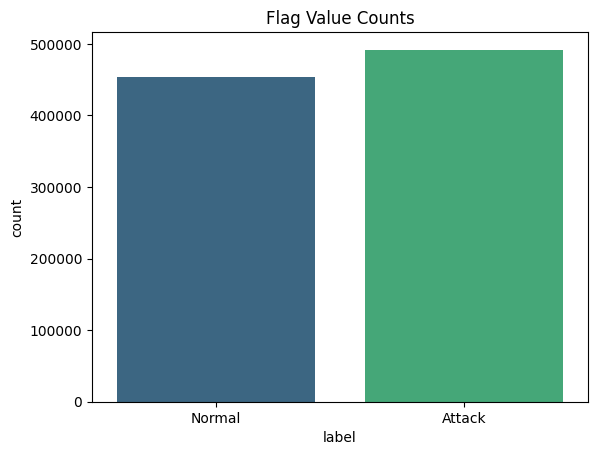

 Label distribution in the Training data (array([0., 1.], dtype=float32), array([318065, 344295]))
 Label distribution in the Test data (array([0., 1.], dtype=float32), array([136314, 147555]))
Label Category in Vehicle 0 : {0.0, 1.0}
Number of Samples in Vehicle 0 : 1204
Label Counts in Vehicle 0 : {1.0: 632, 0.0: 572}
*********
Label Category in Vehicle 1 : {0.0, 1.0}
Number of Samples in Vehicle 1 : 14567
Label Counts in Vehicle 1 : {0.0: 10452, 1.0: 4115}
*********
Label Category in Vehicle 2 : {0.0}
Number of Samples in Vehicle 2 : 11158
Label Counts in Vehicle 2 : {0.0: 11158}
*********
Label Category in Vehicle 3 : {0.0, 1.0}
Number of Samples in Vehicle 3 : 12601
Label Counts in Vehicle 3 : {1.0: 8523, 0.0: 4078}
*********
Label Category in Vehicle 4 : {0.0, 1.0}
Number of Samples in Vehicle 4 : 8783
Label Counts in Vehicle 4 : {1.0: 5899, 0.0: 2884}
*********
Label Category in Vehicle 5 : {0.0}
Number of Samples in Vehicle 5 : 20376
Label Counts in Vehicle 5 : {0.0: 20376}
***

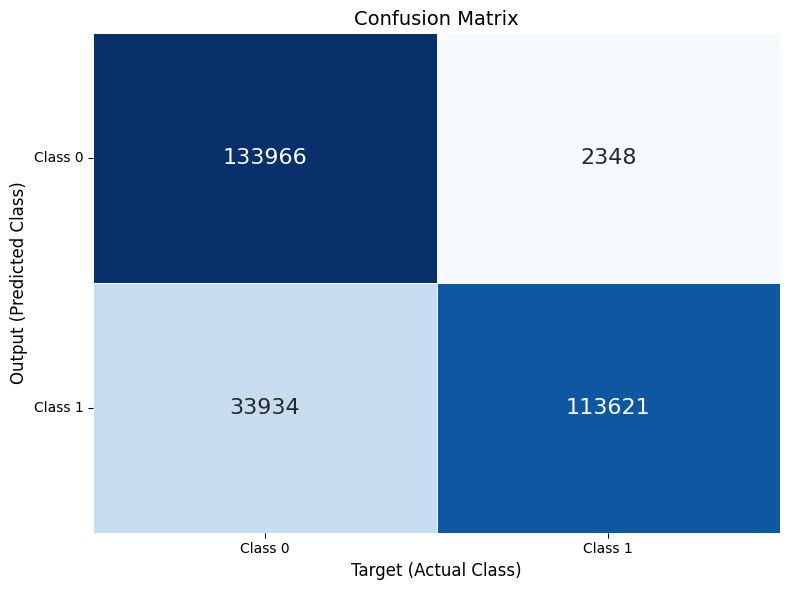

Feature values for instance index {instance_index}:
 {feature_values}


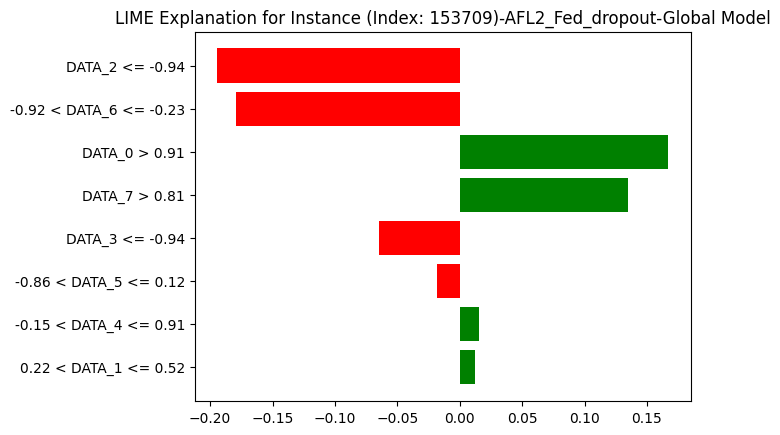

LIME explanation plot saved to /content/drive/MyDrive/car_hacking_results/AFL2_Exp2_09_02_2025/lime_resultslime_explanation_AFL2_Fed_dropout.png
Total time taken for Lime Explanation: 1.35 seconds


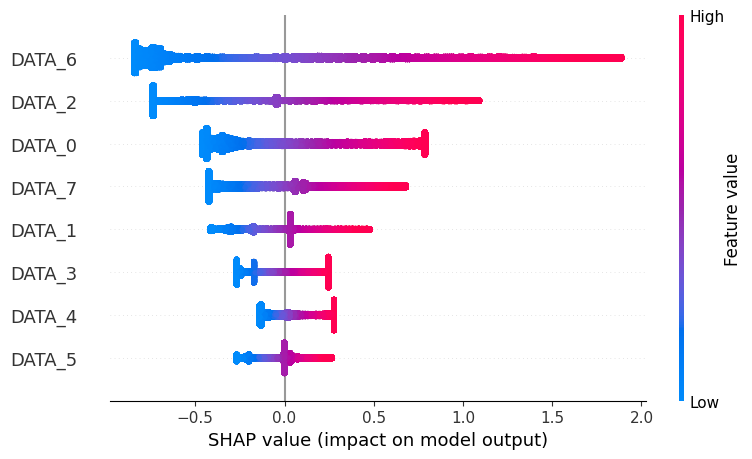

SHAP summary plot saved as /content/drive/MyDrive/car_hacking_results/AFL2_Exp2_09_02_2025/shap_results/shap_summary_AFL2_Fed_dropout.png
Total time taken for Shap Explanation: 851.12 seconds


In [ ]:
import torch
import yaml

# Function to save the model with a specified name format
def save_model(model, round_num, method_name, file_path="model_checkpoint"):
    path=f"/content/drive/MyDrive/car_hacking_results/AFL2_Exp2_09_02_2025/model_checkpoint/{method_name}"
    os.makedirs(path, exist_ok=True)
    model_name = f"{path}/model_{method_name}_round_{round_num}.pth"
    torch.save(model.state_dict(), model_name)
    print(f"Model saved as {model_name}")

# Main Federated Learning (FL) training function
import pandas as pd
import os
import time
import collections
# Main Federated Learning (FL) training function
def run_fl_training(cfg, cloud_server, edge_servers,train_loader,  testloader, X_train_tensor, X_test_tensor,method_name,staleness_threshold, save_path="model_checkpoint"):
    # Initialize variables to store round results
    fl_time = []
    round_results = []
    train_losses = []  # Track training loss for each round
    test_losses = []   # Track testing loss for each round
    # Create the results folder if it doesn't exist
    results_path = f"/content/drive/MyDrive/car_hacking_results/AFL2_Exp2_09_02_2025_Scalability/results"
    os.makedirs(results_path, exist_ok=True)

    # Record the start time
    start_time = time.time()
    total_time=0
    for round_num in range(cfg['num_rounds']):
        print(f'\n  FL Global Training Round AFL2- Federated Dropout - Test size 30 percent - Validation: {round_num+1} \n')
        #cloud_server.reset_version() ## To reset all vehicles,cloud server,vehicles versions before each round
        round_start_time = time.time()  # Start time for this round
        cloud_server.diffusing_global_model()
        edge_times = model_version_control_fed_dropout(edge_servers, cloud_server, staleness_threshold)

        # Calculate the total time for this round
        total_round_time = time.time() - round_start_time  # Calculate round time
        fl_time.append(total_round_time)  # Store round time
        total_time += total_round_time ## Total time

        # Evaluating model performance
        loss, accuracy, precision, recall, f1, conf_matrix = evaluate_model(cloud_server.model, testloader)
        print(f'Loss = {loss}, Accuracy = {accuracy}, Precision = {precision}, Recall = {recall}, F1 score = {f1}, Total Time for round {round_num + 1}= {total_round_time:.2f} seconds')
        train_loss, _, _, _, _, _ = evaluate_model(cloud_server.model,train_loader)
        train_losses.append(train_loss)
        test_losses.append(loss)
        #  Save the model after each round
        save_model(cloud_server.model, round_num + 1, method_name, file_path=save_path)
        print(f"{200 * '*'}")

        # Append results to the round_results list
        round_results.append({
            "Round": round_num + 1,
            "Loss": loss,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1 Score": f1,
            "edge nodes Time for each round": edge_times,
            "Train_Loss":train_loss,
            "Test_loss":loss
        })

    ## 8. Test After Final FL Round
    loss, accuracy, precision, recall, f1, conf_matrix = evaluate_model(cloud_server.model, testloader)
    print(f'Final model results: loss = {loss}, accuracy = {accuracy}, precision = {precision}, recall = {recall}, F1 = {f1} \n confusion matrix: {conf_matrix}')

    # Collecting round results
    round_results.append({
        "Round": round_num + 1,
        "Loss": loss,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "Total Round Time": total_round_time,  # Store the time taken for this round
    })

    print(f"{200 * '*'}")
    print(f"\nTotal training time for all rounds: {total_time:.2f} seconds\n")
    # Final model evaluation
    # Measure testing time
    start_time = time.time()
    loss, accuracy, precision, recall, f1, conf_matrix = evaluate_model(cloud_server.model, testloader)
    end_time = time.time()

    testing_time = end_time - start_time

    print(f'Final model results: Loss = {loss}, Accuracy = {accuracy}, Precision = {precision}, Recall = {recall}, F1 = {f1}')
    print(f'Confusion Matrix:\n{conf_matrix}')
    print(f'Testing Time: {testing_time:.2f} seconds')
    # Appending the final round results
    round_results.append({
        "Round": "Final",
        "Loss": loss,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "FL Time": fl_time,  # Include all round times
        "Confusion Matrix": conf_matrix,
    })

    # Saving the final model
    save_model(cloud_server.model, cfg['num_rounds'], method_name, file_path=save_path)

    # Append total time to the round results
    round_results.append({
        "Round": "Total Time",
        "FL Time": total_time,
        "Round Times": fl_time,  # Optional: store each round time
        "Testing Time": testing_time
})

    # Save results to CSV
    df_results = pd.DataFrame(round_results)
    df_results.to_csv(os.path.join(results_path, f"{method_name}_results.csv"), index=False)
    print(f"Training results saved to {results_path}/{method_name}_results.csv")
    plot_confusion_matrix(conf_matrix)
    ## Generate Lime explanation
    lime_start_time = time.time()
    explanation, selected_instance, instance_index = generate_lime_explanation(X_train_tensor, X_test_tensor, cloud_server.model, method_name)
    lime_end_time = time.time()
    lime_time = lime_end_time - lime_start_time
    print(f"Total time taken for Lime Explanation: {lime_time:.2f} seconds")

    # Running SHAP analysis
    shap_start_time = time.time()
    shap_method(cloud_server.model, method_name, X_train_tensor[:100], X_test_tensor)
    shap_end_time = time.time()
    shap_time = shap_end_time - shap_start_time
    print(f"Total time taken for Shap Explanation: {shap_time:.2f} seconds")

    return df_results

# Main function to run the Federated Learning process
def main():
    ## 1. Parse config & get configs
    with open('/content/drive/MyDrive/base-scalability.yaml', 'r') as file:
        cfg = yaml.safe_load(file)
    #  Preprocess the Dataset and ge
    df = preprocess_dataset()
    ## 2. Prepare the dataset
    # Pre-process the dataset by splitting it into training and testing sets
    # The parameter test_size=0.3 indicates that 30% of the data will be used for testing
    x_train, x_test = prepare_training_testing_data(df,test_size=0.3)
    # Convert the training data (x_train) into a PyTorch tensor of type float32
    X_train_tensor = torch.tensor(x_train, dtype=torch.float32)

    # Convert the testing data (x_test) into a PyTorch tensor of type float32
    X_test_tensor = torch.tensor(x_test, dtype=torch.float32)

    # Load the dataset for a specific application (CICIDS dataset)
    # The function returns training and testing datasets, as well as their corresponding targets
    trainset, testset, train_target, test_target = get_car_hacking_dataset()

    print(" Label distribution in the Training data",np.unique(train_target, return_counts=True))
    print(" Label distribution in the Test data",np.unique(test_target, return_counts=True))
    raw_train_loader,trainloaders, testloader = split_dataset(trainset, testset, cfg['num_clients'], cfg['config_fit']['batch_size'], partition='noniid-labeldir', dir_alpha=1)

    analyze_dataloaders(trainloaders)

    ## 3. Define the clients and the model
    init_global_model = ANNModel()
    vehicles = generate_clients(trainloaders, init_global_model.state_dict().values())

    ## 4. Define the edge servers and the cloud server
    edge_servers,edge_server_vehicle_map = spawn_edge_servers(vehicles, cfg['num_edges'], cfg['config_fit'], init_global_model.state_dict().values())
    cloud_server = CloudServer(edge_servers)
    staleness_threshold=2
    ## 6. Run the FL simulation based on user input
    results=run_fl_training(cfg, cloud_server, edge_servers,raw_train_loader, testloader, X_train_tensor, X_test_tensor, method_name="AFL2_Fed_dropout",staleness_threshold=staleness_threshold, save_path="model_checkpoint")
    return results
if __name__ == "__main__":
    results = main()


In [ ]:
method_name="AFL2_Fed_Dropout"
results_path = f"/content/drive/MyDrive/car_hacking_results/AFL2_Exp2_09_02_2025_Scalability/results"
plot_path = f"{results_path}_{method_name}.png"

df_plot = results[pd.to_numeric(results['Round'], errors='coerce').notnull()]
# Plotting the training and test loss per round
plt.figure(figsize=(10, 6))
plt.plot(df_plot['Round'], df_plot['Train_Loss'], label="Training Loss", marker='o')
plt.plot(df_plot['Round'], df_plot['Test_loss'], label="Testing Loss", marker='o')
plt.xlabel("FL Training Round")
plt.ylabel("Loss")
plt.title("Training and Testing Loss per Federated Learning Round")
plt.xticks(df_plot['Round'].astype(int))  # Display only the round numbers on the x-axis
plt.legend()
plt.grid(True)

# Save the plot
plot_path = f"{results_path}/{method_name}.png"
plt.savefig(plot_path, bbox_inches='tight')
plt.show()